# ML-Based Momentum Trading Strategy
**Hackathon Submission**

**Strategy:** Long-only weekly momentum — top-2 stocks by predicted probability of positive next-week return  
**Universe:** AAPL, MSFT, GOOGL, AMZN, META, TSLA, JPM, V, JNJ, BRK-B  
**Data:** 2017–2025 daily OHLCV (yfinance)  
**Train:** 2017–2022 | **Test:** 2023–2025  
**Models:** Logistic Regression, Random Forest, XGBoost, Soft-Voting Ensemble  
**Transaction Costs:** 0.1% entry + 0.1% exit

---
## Section 0 — Imports & Configuration

In [ ]:
%matplotlib widget
import warnings
warnings.filterwarnings('ignore')

# Data
import yfinance as yf
import pandas as pd
import numpy as np

# ML
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Display
from IPython.display import display
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# ── CONFIG ─────────────────────────────────────────────────────────────────
TICKERS      = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'JPM', 'V', 'JNJ', 'BRK-B']
START        = '2017-01-01'
END          = '2025-12-31'
TRAIN_END    = '2022-12-31'
TEST_START   = '2023-01-01'
TOP_N        = 2              # top stocks selected each week
COST_BPS     = 0.001          # 0.1% one-way transaction cost
RANDOM_STATE = 42

# Data-quality control
USE_ADJ_CLOSE = True    # use split/dividend-adjusted close where available

print('Configuration loaded.')
print(f'Universe: {TICKERS}')
print(f'Train: {START} → {TRAIN_END} | Test: {TEST_START} → {END}')
print(f'Use adjusted close: {USE_ADJ_CLOSE}')

Configuration loaded.
Universe: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'JPM', 'V', 'JNJ', 'BRK-B']
Train: 2017-01-01 → 2022-12-31 | Test: 2023-01-01 → 2025-12-31
Use adjusted close: True


---
## Section 1 — Data Download & Quality Check

In [ ]:
import os

print('Loading daily OHLCV data (local data folder first, then yfinance fallback)...')
DATA_DIR = 'data'
keep_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

frames = []
loaded_local = 0
loaded_yf = 0
missing_all = []

for ticker in TICKERS:
    local_path = os.path.join(DATA_DIR, f'{ticker}.csv')
    print(f'  Processing {ticker}...', end=' ', flush=True)

    try:
        if os.path.exists(local_path):
            df = pd.read_csv(local_path)

            # Normalize common CSV formats
            if 'Date' not in df.columns and len(df.columns) > 0:
                first_col = df.columns[0]
                if str(first_col).startswith('Unnamed') or first_col == 'index':
                    df = df.rename(columns={first_col: 'Date'})

            if 'Date' not in df.columns:
                raise ValueError(f'No Date column in {local_path}')

            df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
            df = df.dropna(subset=['Date']).set_index('Date').sort_index()

            # Prefer adjusted close to avoid split-driven return spikes
            if USE_ADJ_CLOSE and 'Adj Close' in df.columns:
                df['Close'] = df['Adj Close']

            for c in keep_cols:
                if c not in df.columns:
                    df[c] = np.nan

            df = df[keep_cols].copy()
            df = df.loc[(df.index >= pd.Timestamp(START)) & (df.index <= pd.Timestamp(END))]
            source = 'LOCAL'
            loaded_local += 1
        else:
            yf_df = yf.download(
                ticker,
                start=START,
                end=END,
                auto_adjust=USE_ADJ_CLOSE,
                progress=False
            )
            if yf_df.empty:
                missing_all.append(ticker)
                print('Missing (local+yfinance)')
                continue

            if hasattr(yf_df.columns, 'nlevels') and yf_df.columns.nlevels > 1:
                yf_df.columns = [c[0] if isinstance(c, tuple) else c for c in yf_df.columns]

            # If not auto-adjusting, still allow adjusted close override if available
            if USE_ADJ_CLOSE and 'Adj Close' in yf_df.columns:
                yf_df['Close'] = yf_df['Adj Close']

            for c in keep_cols:
                if c not in yf_df.columns:
                    yf_df[c] = np.nan

            df = yf_df[keep_cols].copy()
            df.index = pd.to_datetime(df.index)
            source = 'YF'
            loaded_yf += 1

        if df.empty:
            missing_all.append(ticker)
            print(f'Empty ({source})')
            continue

        df.index.name = 'Date'
        df['Ticker'] = ticker
        df = df.reset_index().set_index(['Date', 'Ticker'])
        frames.append(df)
        print(f'OK ({len(df)} rows, {source})')

    except Exception as e:
        missing_all.append(ticker)
        print(f'FAILED: {e}')

prices = pd.concat(frames) if frames else pd.DataFrame(columns=keep_cols)
prices = prices[keep_cols].copy()
prices = prices.sort_index()

if len(prices) == 0:
    raise ValueError('No data loaded from local data folder or yfinance.')

print(f'\nLoaded from local CSVs: {loaded_local}')
print(f'Loaded from yfinance : {loaded_yf}')
if missing_all:
    print(f'Missing tickers      : {sorted(set(missing_all))}')

print(f'\nShape: {prices.shape}')
print(f'Date range: {prices.index.get_level_values("Date").min()} → {prices.index.get_level_values("Date").max()}')
print(f'Tickers present: {sorted(prices.index.get_level_values("Ticker").unique().tolist())}')

Loading daily OHLCV data (local data folder first, then yfinance fallback)...
  Processing AAPL... OK (2261 rows, LOCAL)
  Processing MSFT... OK (2261 rows, LOCAL)
  Processing GOOGL... OK (2261 rows, LOCAL)
  Processing AMZN... OK (2261 rows, LOCAL)
  Processing META... OK (2261 rows, LOCAL)
  Processing TSLA... OK (2261 rows, LOCAL)
  Processing JPM... OK (2261 rows, LOCAL)
  Processing V... OK (2261 rows, LOCAL)
  Processing JNJ... OK (2261 rows, LOCAL)
  Processing BRK-B... OK (2261 rows, LOCAL)

Loaded from local CSVs: 10
Loaded from yfinance : 0

Shape: (22610, 5)
Date range: 2017-01-03 00:00:00 → 2025-12-30 00:00:00
Tickers present: ['AAPL', 'AMZN', 'BRK-B', 'GOOGL', 'JNJ', 'JPM', 'META', 'MSFT', 'TSLA', 'V']


In [ ]:
# Quality check
print('=== NULL COUNTS PER TICKER ===')
null_counts = prices.groupby('Ticker')['Close'].apply(lambda s: s.isna().sum())
print(null_counts.to_string())

# Drop rows with missing Close
before = len(prices)
prices = prices.dropna(subset=['Close'])
print(f'\nDropped {before - len(prices)} rows with missing Close. Remaining: {len(prices)}')

assert len(prices.index.get_level_values('Ticker').unique()) == len(TICKERS), \
    f'Expected {len(TICKERS)} tickers, got {len(prices.index.get_level_values("Ticker").unique())}'
print('\nAll 10 tickers present. Data quality check passed.')

=== NULL COUNTS PER TICKER ===
Ticker
AAPL     0
AMZN     0
BRK-B    0
GOOGL    0
JNJ      0
JPM      0
META     0
MSFT     0
TSLA     0
V        0

Dropped 0 rows with missing Close. Remaining: 22610

All 10 tickers present. Data quality check passed.


---
## Section 2 — Weekly Resampling (W-FRI)

In [ ]:
# Resample daily OHLCV to weekly Friday-close
prices_reset = prices.reset_index()

weekly = (
    prices_reset
    .groupby(['Ticker', pd.Grouper(key='Date', freq='W-FRI')])
    .agg(Open=('Open', 'first'), High=('High', 'max'), Low=('Low', 'min'),
         Close=('Close', 'last'), Volume=('Volume', 'sum'))
    .swaplevel()
    .sort_index()
)
weekly.index.names = ['Date', 'Ticker']

# Drop weeks where no trading occurred (Close is NaN)
weekly = weekly.dropna(subset=['Close'])

print(f'Weekly shape: {weekly.shape}')
print(f'Date range: {weekly.index.get_level_values("Date").min()} → {weekly.index.get_level_values("Date").max()}')
print(f'Unique weeks: {weekly.index.get_level_values("Date").nunique()}')
weekly.head(10)

Weekly shape: (4700, 5)
Date range: 2017-01-06 00:00:00 → 2026-01-02 00:00:00
Unique weeks: 470


Open     High      Low    Close     Volume
Date       Ticker                                               
2017-01-06 AAPL    28.9500  29.5400  28.6900  27.1511  415382000
           AMZN    37.8960  39.9720  37.3850  39.7995  356958000
           BRK-B  164.3400 164.7100 162.1800 163.4100   13339400
           GOOGL   40.0310  41.4480  39.8445  40.9223  136638000
           JNJ    115.7800 117.0000 115.2300  90.1791   23220500
           JPM     87.3400  87.7600  85.2600  67.7168   63011400
           META   116.0300 123.8800 115.5100 122.5539   88332300
           MSFT    62.7900  63.1500  62.0300  56.4045   86833000
           TSLA    14.3240  15.3540  14.0640  15.2673  428646000
           V       78.7600  82.4900  78.4900  77.0711   38521700

---
## Section 3 — Feature Engineering

**Lookahead bias prevention:** Every feature uses `.shift(1)` (i.e., is lagged by 1 week) before entering `feat`. This ensures that at prediction time for week T, we only use information available through week T-1.

In [ ]:
# ── Helper: unstack Close and Volume to wide format (rows=Date, cols=Ticker) ──
close  = weekly['Close'].unstack('Ticker')   # shape: (n_weeks, 10)
volume = weekly['Volume'].unstack('Ticker')

# Initialize feature DataFrame with same MultiIndex as weekly
feat = pd.DataFrame(index=weekly.index)

# ── 3.1 Return Features ──────────────────────────────────────────────────────
print('Engineering return features...')
for col, periods in [('ret_1w', 1), ('ret_2w', 2), ('ret_4w', 4),
                     ('ret_13w', 13), ('ret_26w', 26), ('ret_52w', 52)]:
    r = close.pct_change(periods).shift(1)    # shift(1) = use LAST week's data
    feat[col] = r.stack(future_stack=True).reindex(feat.index)

# ── 3.2 RSI (14-period) ──────────────────────────────────────────────────────
print('Engineering RSI...')
def compute_rsi(series, window=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window).mean()
    rs    = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

rsi = close.apply(compute_rsi)
feat['rsi_14'] = rsi.shift(1).stack(future_stack=True).reindex(feat.index)

# ── 3.3 MACD ─────────────────────────────────────────────────────────────────
print('Engineering MACD...')
ema12  = close.ewm(span=12, adjust=False).mean()
ema26  = close.ewm(span=26, adjust=False).mean()
macd   = ema12 - ema26
signal = macd.ewm(span=9, adjust=False).mean()
macd_hist = (macd - signal) / close.replace(0, np.nan)   # price-normalized histogram
macd_line = macd / close.replace(0, np.nan)

feat['macd_hist'] = macd_hist.shift(1).stack(future_stack=True).reindex(feat.index)
feat['macd_line'] = macd_line.shift(1).stack(future_stack=True).reindex(feat.index)

# ── 3.4 Bollinger Bands (20-week) ────────────────────────────────────────────
print('Engineering Bollinger Bands...')
roll_mean = close.rolling(20).mean()
roll_std  = close.rolling(20).std()
bb_upper  = roll_mean + 2 * roll_std
bb_lower  = roll_mean - 2 * roll_std
pct_b     = (close - bb_lower) / (bb_upper - bb_lower).replace(0, np.nan)
bb_width  = (bb_upper - bb_lower) / roll_mean.replace(0, np.nan)

feat['bb_pct_b'] = pct_b.shift(1).stack(future_stack=True).reindex(feat.index)
feat['bb_width'] = bb_width.shift(1).stack(future_stack=True).reindex(feat.index)

# ── 3.5 Volume Features ──────────────────────────────────────────────────────
print('Engineering volume features...')
vol_ratio = volume / volume.rolling(4).mean().replace(0, np.nan)
feat['vol_ratio_4w'] = vol_ratio.shift(1).stack(future_stack=True).reindex(feat.index)

# OBV z-score
obv_raw = (np.sign(close.diff()) * volume).cumsum()
obv_z   = (obv_raw - obv_raw.rolling(52).mean()) / obv_raw.rolling(52).std().replace(0, np.nan)
feat['obv_zscore'] = obv_z.shift(1).stack(future_stack=True).reindex(feat.index)

# ── 3.6 Volatility Features ──────────────────────────────────────────────────
print('Engineering volatility features...')
log_ret = np.log(close / close.shift(1))
vol_4w  = log_ret.rolling(4).std()  * np.sqrt(52)
vol_13w = log_ret.rolling(13).std() * np.sqrt(52)

feat['vol_4w']  = vol_4w.shift(1).stack(future_stack=True).reindex(feat.index)
feat['vol_13w'] = vol_13w.shift(1).stack(future_stack=True).reindex(feat.index)

# ── 3.7 Cross-Sectional Rank Features ────────────────────────────────────────
print('Engineering cross-sectional rank features...')
rank_source_cols = ['ret_1w', 'ret_4w', 'ret_13w', 'ret_52w', 'vol_ratio_4w', 'rsi_14']
for col in rank_source_cols:
    ranked = feat[col].unstack('Ticker').rank(axis=1, pct=True)
    feat[f'{col}_xrank'] = ranked.stack(future_stack=True).reindex(feat.index)

# ── 3.8 Target Variable ───────────────────────────────────────────────────────
print('Engineering target...')
fwd_ret = close.pct_change(1).shift(-1)   # NEXT week's return (forward-looking)

# Transparency check: report extreme weekly returns without clipping them
extreme_threshold = 0.40
extreme_obs = (fwd_ret.abs() > extreme_threshold).sum().sum()
print(f'Forward returns beyond +/-{extreme_threshold:.0%}: {int(extreme_obs)} observations (not clipped)')

target  = (fwd_ret > 0).astype(int)

feat['target']  = target.stack(future_stack=True).reindex(feat.index)
feat['fwd_ret'] = fwd_ret.stack(future_stack=True).reindex(feat.index)

# ── Drop NaN rows (warmup period) ─────────────────────────────────────────────
FEATURE_COLS = [c for c in feat.columns if c not in ['target', 'fwd_ret']]
before = len(feat)
feat = feat.dropna(subset=FEATURE_COLS + ['target', 'fwd_ret'])
print(f'\nDropped {before - len(feat)} warmup rows. Remaining: {len(feat)}')
print(f'Features: {FEATURE_COLS}')
print(f'Total features: {len(FEATURE_COLS)}')
feat[FEATURE_COLS].describe().T.head()

Engineering return features...
Engineering RSI...
Engineering MACD...
Engineering Bollinger Bands...
Engineering volume features...
Engineering volatility features...
Engineering cross-sectional rank features...
Engineering target...
Forward returns beyond +/-40%: 0 observations (not clipped)

Dropped 540 warmup rows. Remaining: 4160
Features: ['ret_1w', 'ret_2w', 'ret_4w', 'ret_13w', 'ret_26w', 'ret_52w', 'rsi_14', 'macd_hist', 'macd_line', 'bb_pct_b', 'bb_width', 'vol_ratio_4w', 'obv_zscore', 'vol_4w', 'vol_13w', 'ret_1w_xrank', 'ret_4w_xrank', 'ret_13w_xrank', 'ret_52w_xrank', 'vol_ratio_4w_xrank', 'rsi_14_xrank']
Total features: 21


,count,mean,std,min,25%,50%,75%,max
ret_1w,4160.0000,0.0047,0.0458,-0.2586,-0.0187,0.0044,0.0260,0.3334
ret_2w,4160.0000,0.0094,0.0643,-0.3923,-0.0227,0.0096,0.0403,0.6094
ret_4w,4160.0000,0.0190,0.0939,-0.5255,-0.0305,0.0177,0.0610,0.7634
ret_13w,4160.0000,0.0627,0.1820,-0.5527,-0.0305,0.0486,0.1367,1.7054
ret_26w,4160.0000,0.1308,0.3089,-0.5544,-0.0137,0.0919,0.2170,4.1710


---
## Section 4 — Train / Test Split

In [ ]:
dates = feat.index.get_level_values('Date')
train_mask = dates <= TRAIN_END
test_mask  = dates >= TEST_START

X_train = feat.loc[train_mask, FEATURE_COLS]
y_train = feat.loc[train_mask, 'target']
X_test  = feat.loc[test_mask,  FEATURE_COLS]
y_test  = feat.loc[test_mask,  'target']

print(f'Train: {X_train.index.get_level_values("Date").min().date()} → {X_train.index.get_level_values("Date").max().date()}')
print(f'Test : {X_test.index.get_level_values("Date").min().date()} → {X_test.index.get_level_values("Date").max().date()}')
print(f'Train samples: {len(X_train):,} | Test samples: {len(X_test):,}')
print(f'Train positive rate: {y_train.mean():.2%} | Test positive rate: {y_test.mean():.2%}')

Train: 2018-01-12 → 2022-12-30
Test : 2023-01-06 → 2025-12-26
Train samples: 2,600 | Test samples: 1,560
Train positive rate: 54.50% | Test positive rate: 57.37%


---
## Section 5 — Model Training

In [ ]:
# ── 5.1 Logistic Regression ───────────────────────────────────────────────────
print('Training Logistic Regression...')
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
        C=0.1,
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])
lr_pipe.fit(X_train, y_train)
print('  Done.')

# ── 5.2 Random Forest ─────────────────────────────────────────────────────────
print('Training Random Forest...')
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=20,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf_clf.fit(X_train, y_train)
print('  Done.')

# ── 5.3 XGBoost ────────────────────────────────────────────────────────────────
print('Training XGBoost...')
scale_pos = float((y_train == 0).sum()) / float((y_train == 1).sum())
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_clf.fit(X_train, y_train)
print('  Done.')

# ── 5.4 Voting Ensemble ────────────────────────────────────────────────────────
print('Training Voting Ensemble (LR + RF + XGB)...')
ensemble = VotingClassifier(
    estimators=[
        ('lr',  lr_pipe),
        ('rf',  rf_clf),
        ('xgb', xgb_clf)
    ],
    voting='soft',
    weights=[1, 2, 2]   # downweight LR slightly
)
ensemble.fit(X_train, y_train)
print('  Done.\n')

# ── 5.5 Training Evaluation ────────────────────────────────────────────────────
print('=== TRAINING SET AUC (in-sample) ===')
models = [('Logistic Regression', lr_pipe),
          ('Random Forest',        rf_clf),
          ('XGBoost',              xgb_clf),
          ('Ensemble',             ensemble)]

for name, clf in models:
    prob = clf.predict_proba(X_train)[:, 1]
    auc  = roc_auc_score(y_train, prob)
    print(f'  {name:<25} Train AUC: {auc:.4f}')

Training Logistic Regression...
  Done.
Training Random Forest...
  Done.
Training XGBoost...
  Done.
Training Voting Ensemble (LR + RF + XGB)...
  Done.

=== TRAINING SET AUC (in-sample) ===
  Logistic Regression       Train AUC: 0.5662
  Random Forest             Train AUC: 0.6904
  XGBoost                   Train AUC: 0.8672
  Ensemble                  Train AUC: 0.8127


In [ ]:
# Test set AUC (out-of-sample, informational only — not used for model selection)
print('=== TEST SET AUC (out-of-sample) ===')
for name, clf in models:
    prob = clf.predict_proba(X_test)[:, 1]
    auc  = roc_auc_score(y_test, prob)
    print(f'  {name:<25} Test AUC:  {auc:.4f}')

print('\n=== CLASSIFICATION REPORT (Ensemble, Test Set) ===')
test_pred = ensemble.predict(X_test)
print(classification_report(y_test, test_pred, target_names=['Down', 'Up']))

=== TEST SET AUC (out-of-sample) ===
  Logistic Regression       Test AUC:  0.4821
  Random Forest             Test AUC:  0.4701
  XGBoost                   Test AUC:  0.4945
  Ensemble                  Test AUC:  0.4865

=== CLASSIFICATION REPORT (Ensemble, Test Set) ===
              precision    recall  f1-score   support

        Down       0.41      0.40      0.41       665
          Up       0.57      0.58      0.57       895

    accuracy                           0.50      1560
   macro avg       0.49      0.49      0.49      1560
weighted avg       0.50      0.50      0.50      1560



---
## Section 6 — Walk-Forward Retraining (Optional / Advanced)

Expands the training window by 4 weeks at a time and retrains XGBoost. Results stored separately.

In [ ]:
RUN_WALK_FORWARD = True   # set False to skip
RETRAIN_FREQ     = 4      # retrain every N weeks

wf_predictions = {}   # {date: {ticker: prob}}

if RUN_WALK_FORWARD:
    print('Running walk-forward retraining...')
    all_dates  = feat.index.get_level_values('Date').unique().sort_values()
    test_dates = all_dates[all_dates >= TEST_START]
    wf_clf     = None

    xgb_params = dict(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0
    )

    for i, dt in enumerate(test_dates):
        if i % RETRAIN_FREQ == 0:
            train_data = feat.loc[feat.index.get_level_values('Date') < dt]
            if len(train_data) == 0:
                continue
            X_wf = train_data[FEATURE_COLS]
            y_wf = train_data['target']
            sp   = float((y_wf == 0).sum()) / max(float((y_wf == 1).sum()), 1)
            wf_clf = xgb.XGBClassifier(scale_pos_weight=sp, **xgb_params)
            wf_clf.fit(X_wf, y_wf)

        if wf_clf is None:
            continue

        week_X = feat.loc[feat.index.get_level_values('Date') == dt, FEATURE_COLS]
        if len(week_X) == 0:
            continue
        tickers_this_week = week_X.index.get_level_values('Ticker').tolist()
        probs = wf_clf.predict_proba(week_X)[:, 1]
        wf_predictions[dt] = dict(zip(tickers_this_week, probs))

    print(f'Walk-forward complete. Predictions for {len(wf_predictions)} weeks.')
else:
    print('Walk-forward skipped. Using static ensemble model for backtesting.')

Running walk-forward retraining...
Walk-forward complete. Predictions for 156 weeks.


---
## Section 7 — Backtesting Loop

In [ ]:
# Generate probabilities for the test period from the ensemble model
prob_df = feat.loc[test_mask, FEATURE_COLS].copy()
prob_df['prob']    = ensemble.predict_proba(X_test)[:, 1]
prob_df['fwd_ret'] = feat.loc[test_mask, 'fwd_ret']

# If walk-forward was run, override with walk-forward probabilities
if RUN_WALK_FORWARD and len(wf_predictions) > 0:
    print('Using walk-forward predictions for backtesting.')
    for dt, ticker_probs in wf_predictions.items():
        for ticker, prob in ticker_probs.items():
            if (dt, ticker) in prob_df.index:
                prob_df.loc[(dt, ticker), 'prob'] = prob
else:
    print('Using static ensemble predictions for backtesting.')

print(f'Prediction DataFrame shape: {prob_df.shape}')

Using walk-forward predictions for backtesting.
Prediction DataFrame shape: (1560, 23)


In [ ]:
# ── Weekly rebalancing backtest ────────────────────────────────────────────────
test_dates_sorted = prob_df.index.get_level_values('Date').unique().sort_values()
prev_holdings = set()   # tracks last week's held tickers
backtest_rows = []

for dt in test_dates_sorted:
    week_data = prob_df.xs(dt, level='Date')   # index = Ticker

    # Require at least TOP_N stocks with valid predictions
    valid = week_data.dropna(subset=['prob', 'fwd_ret'])
    if len(valid) < TOP_N:
        continue

    # Rank by predicted probability, descending → select top 2
    ranked   = valid['prob'].nlargest(TOP_N)
    selected = list(ranked.index)
    weight   = 1.0 / TOP_N   # equal weight = 0.5 each

    # Realized returns for selected stocks this week
    week_rets  = valid.loc[selected, 'fwd_ret']
    gross_ret  = (week_rets * weight).sum()

    # Transaction costs: only charge for positions that CHANGE
    entered = set(selected) - prev_holdings
    exited  = prev_holdings - set(selected)
    cost    = (len(entered) + len(exited)) * weight * COST_BPS
    net_ret = gross_ret - cost

    backtest_rows.append({
        'Date'              : dt,
        'stock_1'           : selected[0],
        'stock_2'           : selected[1],
        'prob_1'            : ranked.iloc[0],
        'prob_2'            : ranked.iloc[1],
        'weight_1'          : weight,
        'weight_2'          : weight,
        'ret_stock_1'       : valid.loc[selected[0], 'fwd_ret'],
        'ret_stock_2'       : valid.loc[selected[1], 'fwd_ret'],
        'gross_weekly_ret'  : gross_ret,
        'transaction_cost'  : cost,
        'net_weekly_ret'    : net_ret,
        'hit'               : int(gross_ret > 0),
    })
    prev_holdings = set(selected)

results = pd.DataFrame(backtest_rows).set_index('Date')

# Add equal-weight benchmark (mean of all 10 stocks' fwd returns each week)
bm_rets = feat.loc[test_mask, 'fwd_ret'].unstack('Ticker').mean(axis=1)
bm_rets.name = 'benchmark_ret'
results = results.join(bm_rets, how='left')

print(f'Backtest complete. {len(results)} weeks of results.')
print(f'Date range: {results.index.min().date()} → {results.index.max().date()}')
results[['stock_1', 'stock_2', 'gross_weekly_ret', 'net_weekly_ret', 'hit']].head(10)

Backtest complete. 156 weeks of results.
Date range: 2023-01-06 → 2025-12-26


,stock_1,stock_2,gross_weekly_ret,net_weekly_ret,hit
Date,,,,,
2023-01-06,JPM,JNJ,-0.0005,-0.0015,0
2023-01-13,JPM,V,-0.0249,-0.0259,0
2023-01-20,V,JPM,0.0353,0.0353,1
2023-01-27,V,JPM,-0.0001,-0.0001,0
2023-02-03,JNJ,TSLA,0.0107,0.0087,1
2023-02-10,META,V,-0.0117,-0.0137,0
2023-02-17,BRK-B,JNJ,-0.0206,-0.0226,0
2023-02-24,BRK-B,JNJ,0.0076,0.0076,1
2023-03-03,BRK-B,V,-0.0312,-0.0322,0


---
## Section 8 — Performance Metrics

In [ ]:
def compute_metrics(weekly_returns: pd.Series, label: str) -> dict:
    """Compute standard performance metrics for a series of weekly returns."""
    wr    = weekly_returns.dropna()
    cum   = (1 + wr).cumprod()
    n     = len(wr)

    total_ret   = cum.iloc[-1] - 1
    ann_ret     = (1 + total_ret) ** (52 / n) - 1
    ann_vol     = wr.std() * np.sqrt(52)
    sharpe      = ann_ret / ann_vol if ann_vol > 0 else np.nan

    rolling_max = cum.cummax()
    drawdown    = (cum - rolling_max) / rolling_max
    max_dd      = drawdown.min()

    hit_rate    = (wr > 0).mean()
    avg_wk_ret  = wr.mean()

    return {
        'Strategy'             : label,
        'Cumulative Return'    : f'{total_ret:.2%}',
        'Annualized Return'    : f'{ann_ret:.2%}',
        'Annualized Volatility': f'{ann_vol:.2%}',
        'Sharpe Ratio'         : f'{sharpe:.3f}',
        'Max Drawdown'         : f'{max_dd:.2%}',
        'Hit Rate'             : f'{hit_rate:.2%}',
        'Avg Weekly Return'    : f'{avg_wk_ret:.4%}',
        'N Weeks'              : n,
    }


m_gross = compute_metrics(results['gross_weekly_ret'], 'Strategy (Gross of Costs)')
m_net   = compute_metrics(results['net_weekly_ret'],   'Strategy (Net of Costs)')
m_bm    = compute_metrics(results['benchmark_ret'],    'EW Benchmark')

metrics_df = pd.DataFrame([m_gross, m_net, m_bm]).set_index('Strategy')
print('=== PERFORMANCE SUMMARY (Test Period 2023–2025) ===')
display(metrics_df.drop(columns='N Weeks').T)

=== PERFORMANCE SUMMARY (Test Period 2023–2025) ===


Strategy,Strategy (Gross of Costs),Strategy (Net of Costs),EW Benchmark
Cumulative Return,203.06%,156.07%,168.18%
Annualized Return,44.71%,36.81%,38.93%
Annualized Volatility,23.30%,23.37%,17.01%
Sharpe Ratio,1.919,1.575,2.289
Max Drawdown,-22.11%,-23.68%,-18.59%
Hit Rate,61.54%,60.90%,63.46%
Avg Weekly Return,0.7639%,0.6556%,0.6619%


---
## Section 9 — Visualizations

### 9.0 Train, Test, and Combined Equity Curves
This chart compares net strategy equity and equal-weight benchmark across train-only, test-only, and the full combined period.

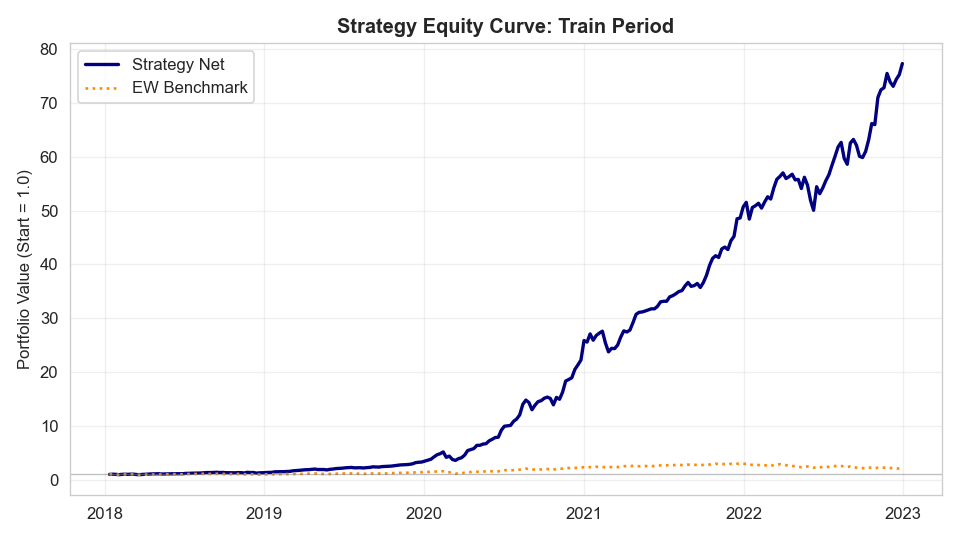

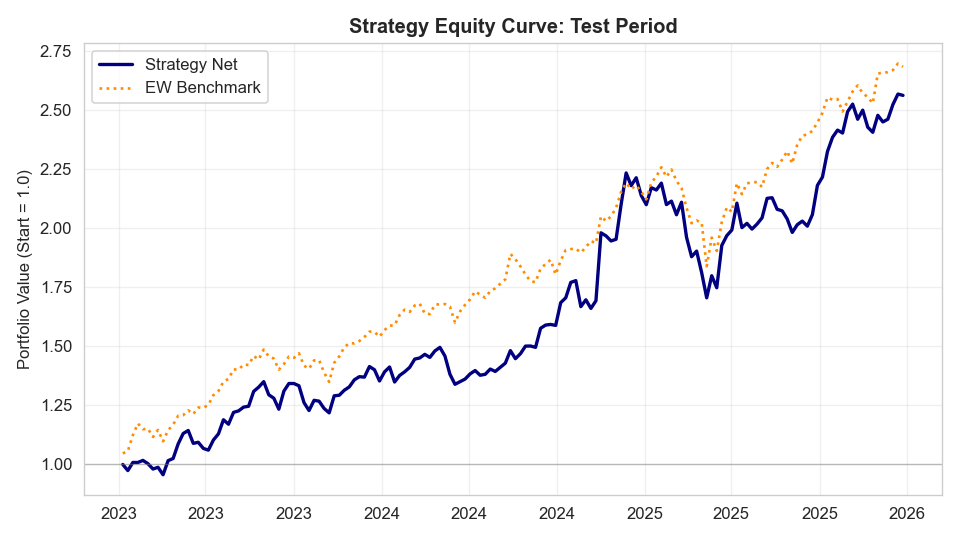

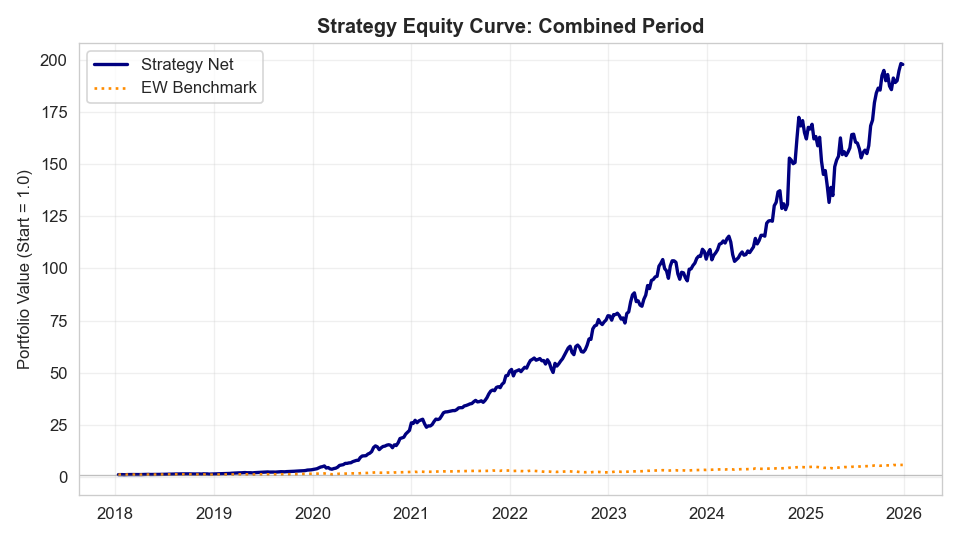

Train weeks: 260 | Test weeks: 156 | Combined weeks: 416


In [ ]:
def run_topn_weekly_backtest(prob_data: pd.DataFrame, top_n: int, cost_bps: float) -> pd.DataFrame:
    """Weekly top-N backtest with turnover-based transaction costs."""
    dates_sorted = prob_data.index.get_level_values('Date').unique().sort_values()
    prev_holdings = set()
    rows = []

    for dt in dates_sorted:
        week_data = prob_data.xs(dt, level='Date')
        valid = week_data.dropna(subset=['prob', 'fwd_ret'])
        if len(valid) < top_n:
            continue

        ranked = valid['prob'].nlargest(top_n)
        selected = list(ranked.index)
        weight = 1.0 / top_n

        week_rets = valid.loc[selected, 'fwd_ret']
        gross_ret = float((week_rets * weight).sum())

        entered = set(selected) - prev_holdings
        exited = prev_holdings - set(selected)
        cost = (len(entered) + len(exited)) * weight * cost_bps
        net_ret = gross_ret - cost

        rows.append({
            'Date': dt,
            'gross_weekly_ret': gross_ret,
            'transaction_cost': cost,
            'net_weekly_ret': net_ret,
        })

        prev_holdings = set(selected)

    if not rows:
        return pd.DataFrame(columns=['gross_weekly_ret', 'transaction_cost', 'net_weekly_ret'])

    return pd.DataFrame(rows).set_index('Date').sort_index()

# Build train and test probability frames
train_prob_df = feat.loc[train_mask, FEATURE_COLS].copy()
train_prob_df['prob'] = ensemble.predict_proba(X_train)[:, 1]
train_prob_df['fwd_ret'] = feat.loc[train_mask, 'fwd_ret']

test_prob_df = prob_df[['prob', 'fwd_ret']].copy()

# Backtest on train and test separately
train_results = run_topn_weekly_backtest(train_prob_df, TOP_N, COST_BPS)
test_results_for_plot = run_topn_weekly_backtest(test_prob_df, TOP_N, COST_BPS)

# Equal-weight benchmarks
train_bm = feat.loc[train_mask, 'fwd_ret'].unstack('Ticker').mean(axis=1)
test_bm = feat.loc[test_mask, 'fwd_ret'].unstack('Ticker').mean(axis=1)

# Align benchmark to valid backtest dates
train_results = train_results.join(train_bm.rename('benchmark_ret'), how='left')
test_results_for_plot = test_results_for_plot.join(test_bm.rename('benchmark_ret'), how='left')

# Combined period
combined_results = pd.concat([train_results, test_results_for_plot]).sort_index()

# Equity curves
train_eq = (1 + train_results['net_weekly_ret']).cumprod()
test_eq = (1 + test_results_for_plot['net_weekly_ret']).cumprod()
combined_eq = (1 + combined_results['net_weekly_ret']).cumprod()

train_bm_eq = (1 + train_results['benchmark_ret']).cumprod()
test_bm_eq = (1 + test_results_for_plot['benchmark_ret']).cumprod()
combined_bm_eq = (1 + combined_results['benchmark_ret']).cumprod()

plot_series = [
    ('Train Period', train_eq, train_bm_eq),
    ('Test Period', test_eq, test_bm_eq),
    ('Combined Period', combined_eq, combined_bm_eq),
]

for title, strat_eq, bm_eq in plot_series:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(strat_eq.index, strat_eq.values, label='Strategy Net', color='navy', lw=2)
    ax.plot(bm_eq.index, bm_eq.values, label='EW Benchmark', color='darkorange', lw=1.6, linestyle=':')
    ax.axhline(1.0, color='grey', lw=0.8, alpha=0.5)
    ax.set_title(f'Strategy Equity Curve: {title}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Portfolio Value (Start = 1.0)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(alpha=0.3)
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

print(f'Train weeks: {len(train_results)} | Test weeks: {len(test_results_for_plot)} | Combined weeks: {len(combined_results)}')

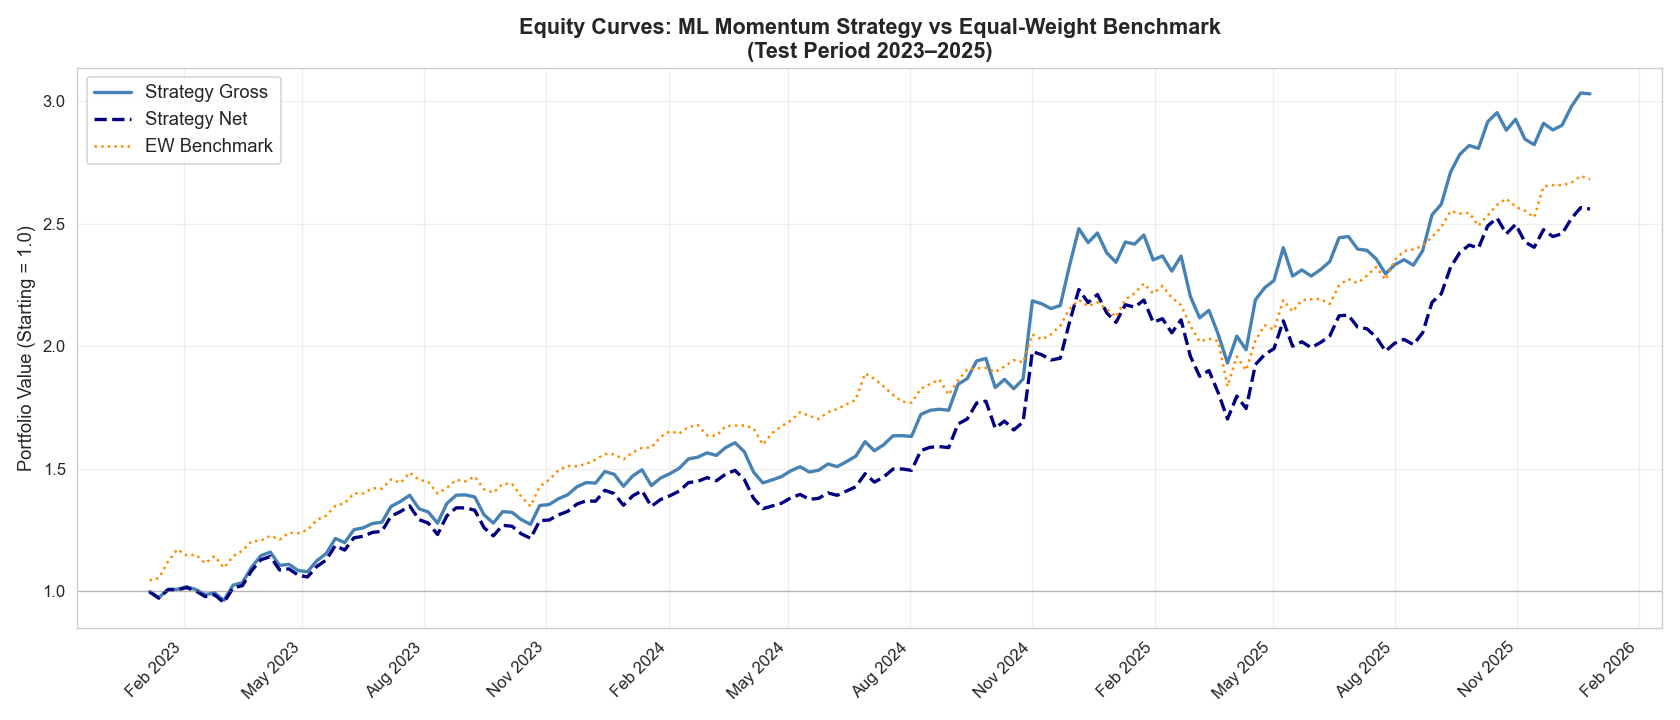

In [ ]:
# ── 9.1 Equity Curves ─────────────────────────────────────────────────────────
cum_gross = (1 + results['gross_weekly_ret']).cumprod()
cum_net   = (1 + results['net_weekly_ret']).cumprod()
cum_bm    = (1 + results['benchmark_ret']).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(cum_gross.index, cum_gross.values, label='Strategy Gross',  color='steelblue',  lw=2)
ax.plot(cum_net.index,   cum_net.values,   label='Strategy Net',    color='navy',       lw=2, linestyle='--')
ax.plot(cum_bm.index,    cum_bm.values,    label='EW Benchmark',    color='darkorange', lw=1.5, linestyle=':')
ax.axhline(1.0, color='grey', lw=0.8, linestyle='-', alpha=0.5)
ax.set_title('Equity Curves: ML Momentum Strategy vs Equal-Weight Benchmark\n(Test Period 2023–2025)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Portfolio Value (Starting = 1.0)', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()

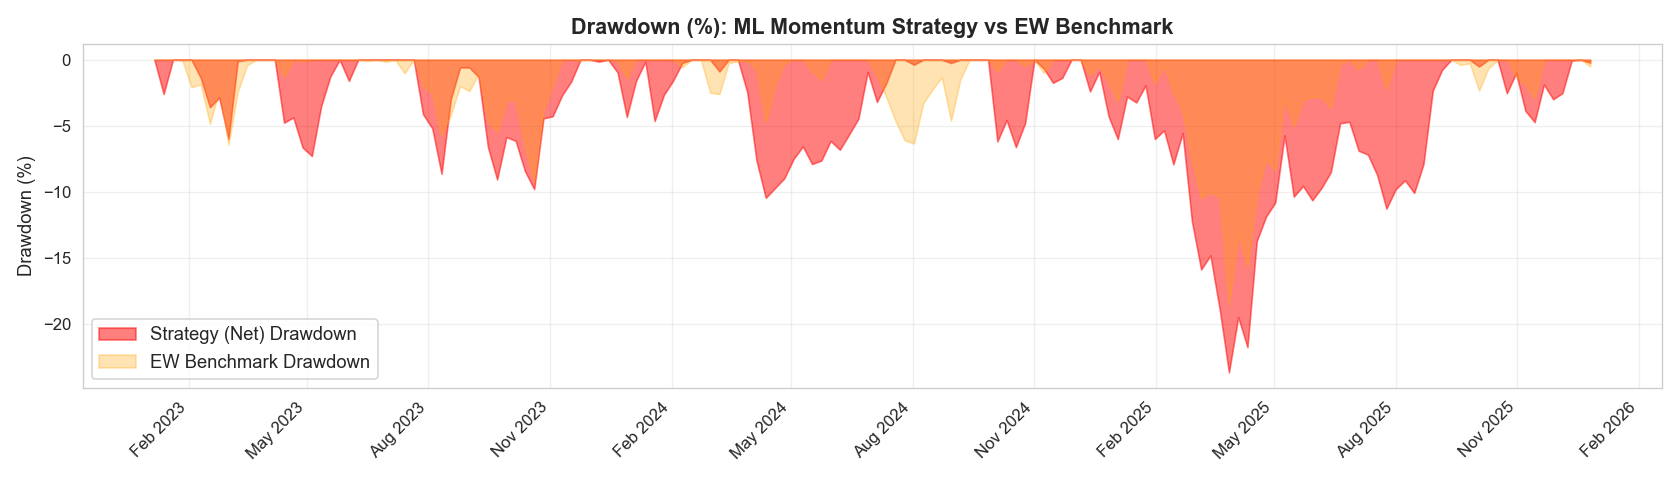

In [ ]:
# ── 9.2 Drawdown Chart ────────────────────────────────────────────────────────
dd_net = (cum_net / cum_net.cummax()) - 1
dd_bm  = (cum_bm  / cum_bm.cummax())  - 1

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(dd_net.index, dd_net.values * 100, 0, alpha=0.5, color='red',    label='Strategy (Net) Drawdown')
ax.fill_between(dd_bm.index,  dd_bm.values  * 100, 0, alpha=0.3, color='orange', label='EW Benchmark Drawdown')
ax.set_title('Drawdown (%): ML Momentum Strategy vs EW Benchmark', fontsize=13, fontweight='bold')
ax.set_ylabel('Drawdown (%)', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

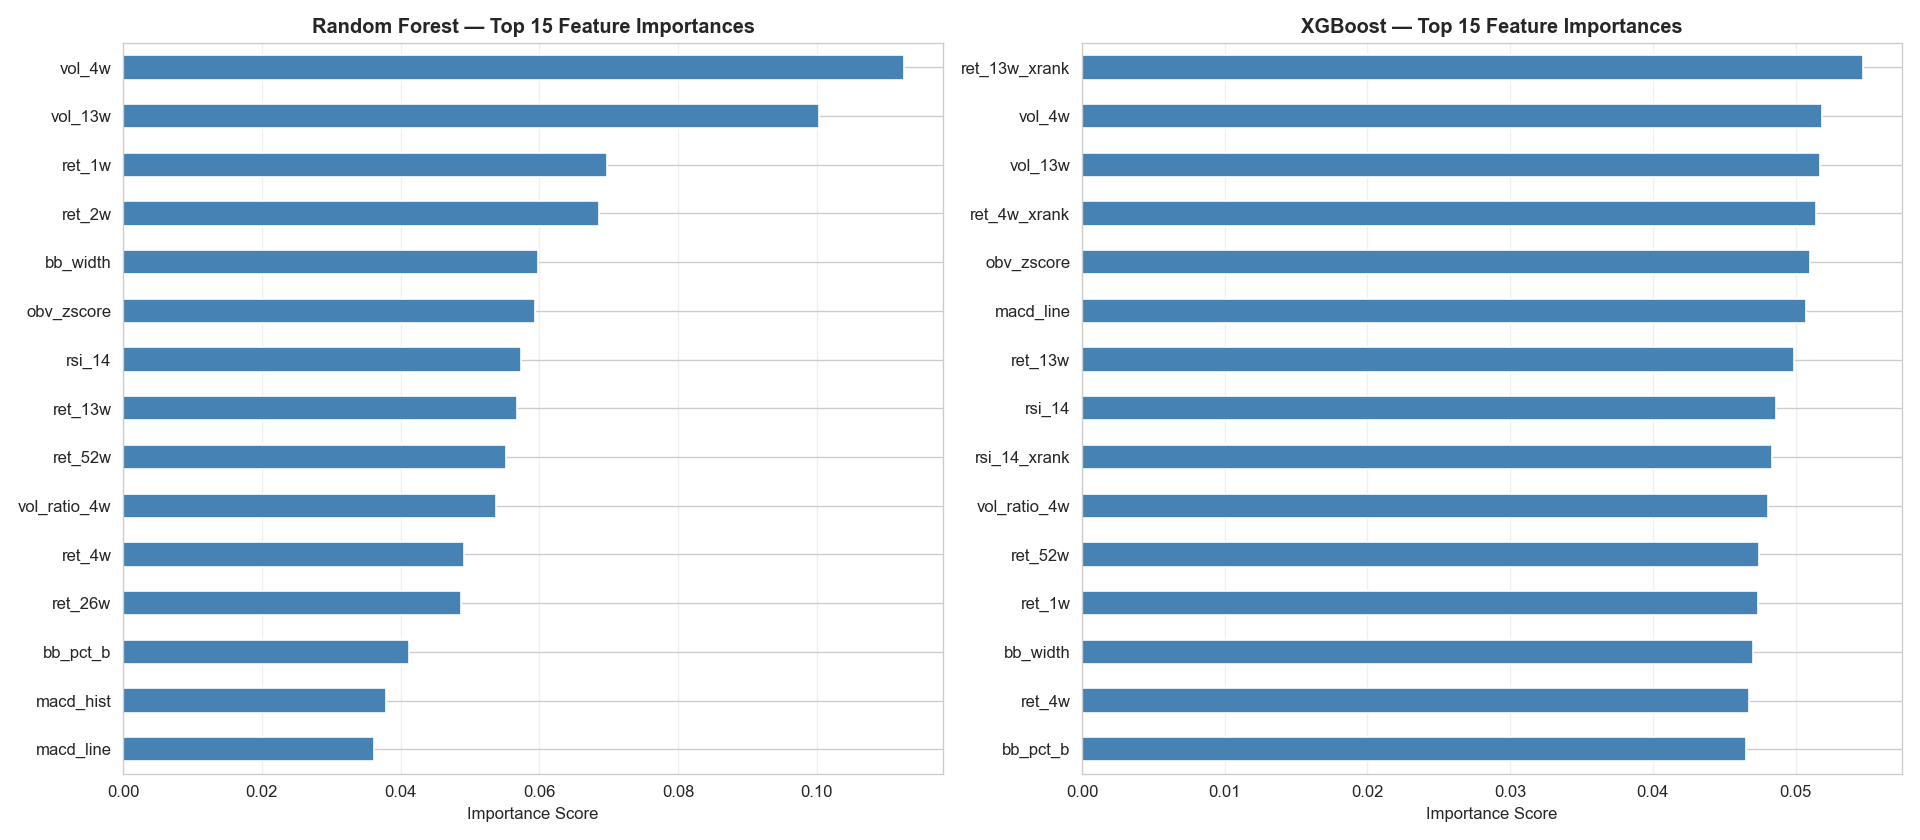

In [ ]:
# ── 9.3 Feature Importance ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (model, name) in zip(axes, [(rf_clf, 'Random Forest'), (xgb_clf, 'XGBoost')]):
    imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).nlargest(15).sort_values()
    colors = ['steelblue'] * len(imp)
    imp.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'{name} — Top 15 Feature Importances', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score', fontsize=10)
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

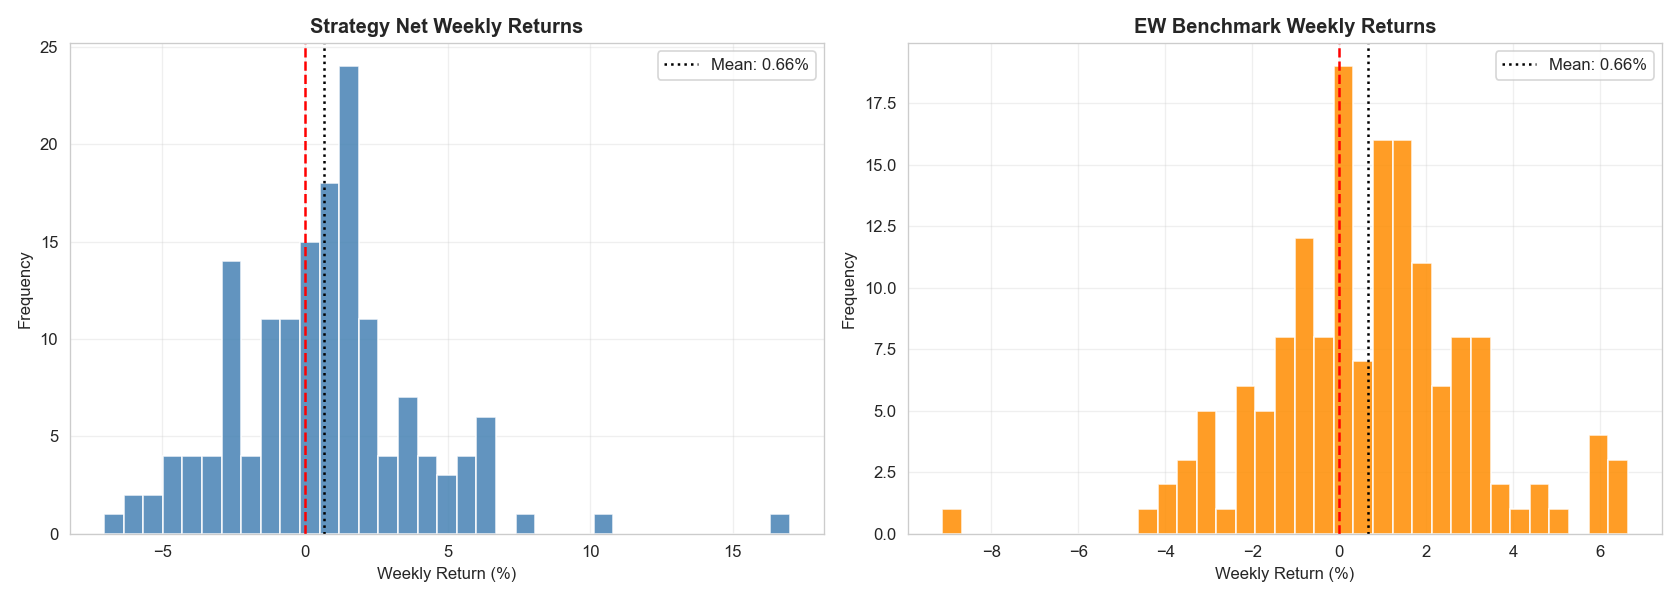

In [ ]:
# ── 9.4 Weekly Returns Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color, title in [
    (axes[0], 'net_weekly_ret',  'steelblue', 'Strategy Net Weekly Returns'),
    (axes[1], 'benchmark_ret',   'darkorange', 'EW Benchmark Weekly Returns')
]:
    data = results[col].dropna() * 100
    ax.hist(data, bins=35, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', lw=1.5, linestyle='--')
    ax.axvline(data.mean(), color='black', lw=1.5, linestyle=':', label=f'Mean: {data.mean():.2f}%')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Weekly Return (%)', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

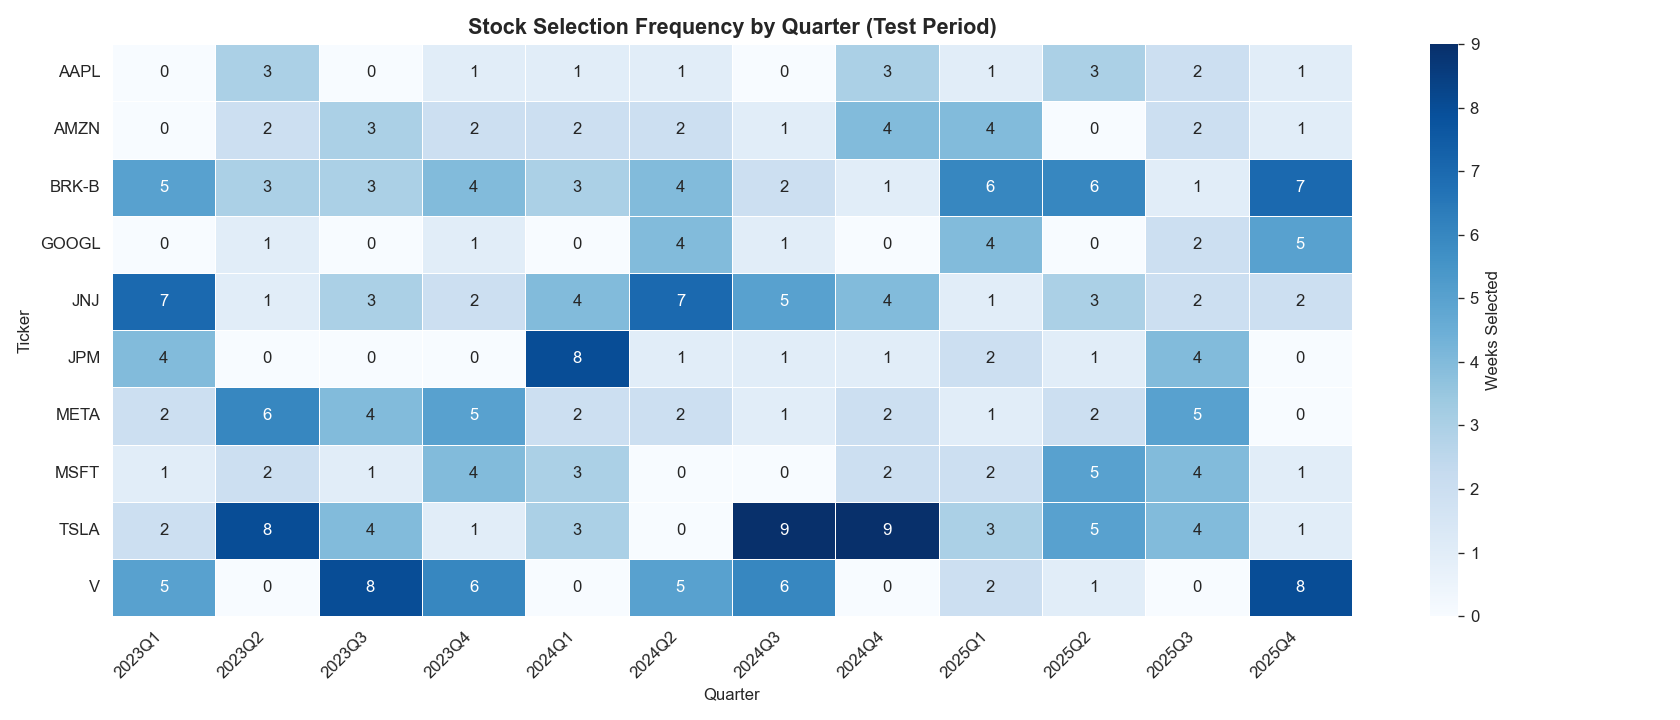

In [ ]:
# ── 9.5 Stock Selection Heatmap ───────────────────────────────────────────────
sel_df = results[['stock_1', 'stock_2']].copy()
sel_df['quarter'] = pd.PeriodIndex(sel_df.index, freq='Q').astype(str)

long_sel = (
    sel_df.reset_index()
    .melt(id_vars=['Date', 'quarter'], value_vars=['stock_1', 'stock_2'], value_name='Ticker')
    .drop(columns='variable')
)
heatmap_data = (
    long_sel.groupby(['quarter', 'Ticker'])
    .size()
    .unstack(fill_value=0)
)

# Ensure all tickers are present
for t in TICKERS:
    if t not in heatmap_data.columns:
        heatmap_data[t] = 0
heatmap_data = heatmap_data[sorted(heatmap_data.columns)]

fig, ax = plt.subplots(figsize=(14, max(5, len(heatmap_data.columns) * 0.6)))
sns.heatmap(
    heatmap_data.T, ax=ax, cmap='Blues', linewidths=0.5,
    annot=True, fmt='d', cbar_kws={'label': 'Weeks Selected'}
)
ax.set_title('Stock Selection Frequency by Quarter (Test Period)', fontsize=13, fontweight='bold')
ax.set_xlabel('Quarter', fontsize=10)
ax.set_ylabel('Ticker', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('stock_selection_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

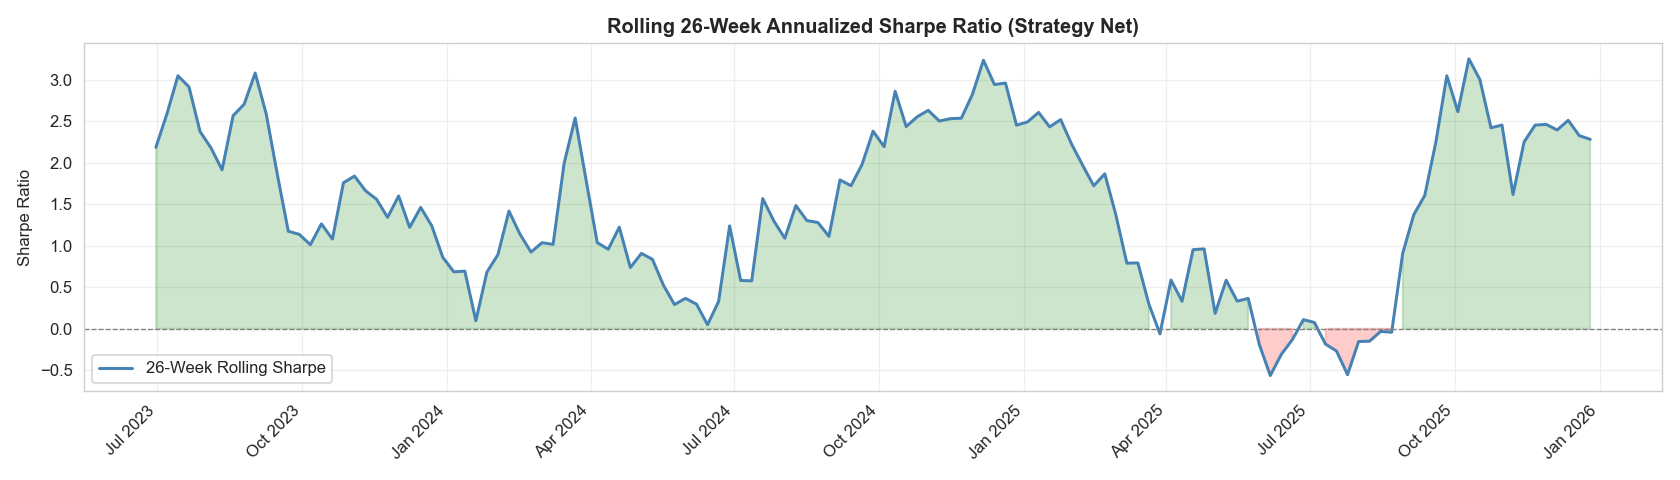

In [ ]:
# ── 9.6 Rolling Sharpe Ratio (26-week window) ─────────────────────────────────
window = 26
roll_sharpe = (
    results['net_weekly_ret'].rolling(window).mean() /
    results['net_weekly_ret'].rolling(window).std()
) * np.sqrt(52)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(roll_sharpe.index, roll_sharpe.values, color='steelblue', lw=1.8, label=f'{window}-Week Rolling Sharpe')
ax.axhline(0, color='grey', lw=0.8, linestyle='--')
ax.fill_between(roll_sharpe.index, roll_sharpe.values, 0,
                where=roll_sharpe.values >= 0, alpha=0.2, color='green')
ax.fill_between(roll_sharpe.index, roll_sharpe.values, 0,
                where=roll_sharpe.values < 0, alpha=0.2, color='red')
ax.set_title(f'Rolling {window}-Week Annualized Sharpe Ratio (Strategy Net)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sharpe Ratio', fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rolling_sharpe.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 10 — CSV Export

In [ ]:
# Add probability columns for ALL tickers (wide format)
prob_wide = prob_df['prob'].unstack('Ticker').add_prefix('prob_')
export_df = results.join(prob_wide, how='left')

# Ordered column list
base_cols = [
    'stock_1', 'stock_2',
    'prob_1', 'prob_2',
    'weight_1', 'weight_2',
    'ret_stock_1', 'ret_stock_2',
    'gross_weekly_ret', 'transaction_cost', 'net_weekly_ret',
    'hit', 'benchmark_ret',
]
prob_ticker_cols = sorted([c for c in export_df.columns if c.startswith('prob_') and len(c) > 6])
all_cols = base_cols + prob_ticker_cols

output_path = 'ml_momentum_predictions.csv'
export_df[all_cols].to_csv(output_path, float_format='%.6f', index_label='Date')

print(f'Saved {len(export_df)} weeks of predictions to: {output_path}')
print(f'Columns: {list(export_df[all_cols].columns)}')
export_df[all_cols].head()

Saved 156 weeks of predictions to: ml_momentum_predictions.csv
Columns: ['stock_1', 'stock_2', 'prob_1', 'prob_2', 'weight_1', 'weight_2', 'ret_stock_1', 'ret_stock_2', 'gross_weekly_ret', 'transaction_cost', 'net_weekly_ret', 'hit', 'benchmark_ret', 'prob_AAPL', 'prob_AMZN', 'prob_BRK-B', 'prob_GOOGL', 'prob_JNJ', 'prob_JPM', 'prob_META', 'prob_MSFT', 'prob_TSLA']


,stock_1,stock_2,prob_1,prob_2,weight_1,weight_2,ret_stock_1,ret_stock_2,gross_weekly_ret,transaction_cost,...,benchmark_ret,prob_AAPL,prob_AMZN,prob_BRK-B,prob_GOOGL,prob_JNJ,prob_JPM,prob_META,prob_MSFT,prob_TSLA
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-06,JPM,JNJ,0.7158,0.6900,0.5000,0.5000,0.0368,-0.0378,-0.0005,0.0010,...,0.0454,0.4295,0.5389,0.4810,0.2853,0.6900,0.7158,0.5147,0.5182,0.3938
2023-01-13,JPM,V,0.6884,0.6230,0.5000,0.5000,-0.0555,0.0056,-0.0249,0.0010,...,0.0089,0.4556,0.4366,0.5985,0.5210,0.5892,0.6884,0.2609,0.4830,0.4694
2023-01-20,V,JPM,0.6592,0.6491,0.5000,0.5000,0.0318,0.0388,0.0353,0.0000,...,0.0644,0.4316,0.4316,0.5982,0.4151,0.5241,0.6491,0.3212,0.4000,0.3572
2023-01-27,V,JPM,0.5940,0.5523,0.5000,0.5000,-0.0057,0.0055,-0.0001,0.0000,...,0.0439,0.4734,0.4417,0.5034,0.4471,0.5440,0.5523,0.3198,0.3522,0.4694
2023-02-03,JNJ,TSLA,0.6378,0.5691,0.5000,0.5000,-0.0149,0.0364,0.0107,0.0020,...,-0.0208,0.4768,0.2189,0.5379,0.4225,0.6378,0.4758,0.5542,0.3636,0.5691


---
## Final Summary

In [ ]:
print('=' * 60)
print('ML MOMENTUM STRATEGY — FINAL SUMMARY')
print('=' * 60)
print(f'Universe      : {len(TICKERS)} stocks | {TICKERS}')
print(f'Data Period   : {START} → {END}')
print(f'Train Period  : {START} → {TRAIN_END}')
print(f'Test Period   : {TEST_START} → {END}')
print(f'Strategy      : Top-{TOP_N} long-only, weekly rebalance')
print(f'Models        : LR + RF + XGB (Soft Voting Ensemble)')
print(f'Transaction   : {COST_BPS*100:.1f}% per side ({COST_BPS*200:.1f}% round-trip)')
print()
print('PERFORMANCE (TEST PERIOD):')
display(metrics_df.drop(columns='N Weeks').T)
print()
print('Outputs saved:')
print('  → ml_momentum_predictions.csv')
print('  → equity_curves.png')
print('  → drawdown.png')
print('  → feature_importance.png')
print('  → return_distribution.png')
print('  → stock_selection_heatmap.png')
print('  → rolling_sharpe.png')

ML MOMENTUM STRATEGY — FINAL SUMMARY
Universe      : 10 stocks | ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'JPM', 'V', 'JNJ', 'BRK-B']
Data Period   : 2017-01-01 → 2025-12-31
Train Period  : 2017-01-01 → 2022-12-31
Test Period   : 2023-01-01 → 2025-12-31
Strategy      : Top-2 long-only, weekly rebalance
Models        : LR + RF + XGB (Soft Voting Ensemble)
Transaction   : 0.1% per side (0.2% round-trip)

PERFORMANCE (TEST PERIOD):


Strategy,Strategy (Gross of Costs),Strategy (Net of Costs),EW Benchmark
Cumulative Return,203.06%,156.07%,168.18%
Annualized Return,44.71%,36.81%,38.93%
Annualized Volatility,23.30%,23.37%,17.01%
Sharpe Ratio,1.919,1.575,2.289
Max Drawdown,-22.11%,-23.68%,-18.59%
Hit Rate,61.54%,60.90%,63.46%
Avg Weekly Return,0.7639%,0.6556%,0.6619%



Outputs saved:
  → ml_momentum_predictions.csv
  → equity_curves.png
  → drawdown.png
  → feature_importance.png
  → return_distribution.png
  → stock_selection_heatmap.png
  → rolling_sharpe.png


---
## Quick Task — Download Stocks and Plot with Matplotlib

In [ ]:
# Download daily adjusted close prices for the hackathon universe
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

start_date = '2017-01-01'
end_date = '2025-12-31'

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'JPM', 'V', 'JNJ', 'BRK-B']

raw = yf.download(
    tickers=tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
    group_by='ticker'
)

# Build a clean close-price table with one column per ticker
close_df = pd.DataFrame(index=raw.index)
for t in tickers:
    if (t, 'Close') in raw.columns:
        close_df[t] = raw[(t, 'Close')]
    elif 'Close' in raw.columns:
        # Fallback if yfinance returns single-level columns for one ticker
        close_df[t] = raw['Close']

close_df = close_df.dropna(how='all')

print(f'Stocks downloaded: {len(close_df.columns)} / {len(tickers)}')
print(f'Date range: {close_df.index.min().date()} to {close_df.index.max().date()}')
close_df.tail()

In [ ]:
# Plot 1: each stock in its own subplot
n = len(close_df.columns)
fig, axes = plt.subplots(n, 1, figsize=(14, 2.6 * n), sharex=True)

if n == 1:
    axes = [axes]

for ax, ticker in zip(axes, close_df.columns):
    ax.plot(close_df.index, close_df[ticker], linewidth=1.4)
    ax.set_title(f'{ticker} Adjusted Close', fontsize=10)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

# Plot 2: normalized comparison (start = 100)
norm_df = close_df / close_df.iloc[0] * 100

plt.figure(figsize=(14, 6))
for ticker in norm_df.columns:
    plt.plot(norm_df.index, norm_df[ticker], label=ticker, linewidth=1.5)

plt.title('Normalized Price Comparison (Start = 100)')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()